In [18]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src import config
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- Shared style constants (McKinsey-adjacent palette) ------------------
STYLE = {
    # Primary ink colors
    "navy":       "#051C2C",   # titles, primary data
    "body":       "#333333",   # body text, annotations
    "muted":      "#555555",   # subtitles, axis labels
    "grid":       "#CCCCCC",   # gridlines
    
    # Sequential blue palette for ordered data
    "blue_darkest":  "#08306B",
    "blue_dark":     "#2171B5",
    "blue_mid":      "#4292C6",
    "blue_light":    "#9ECAE1",
    "blue_palest":   "#C6DBEF",
    
    # Warm neutrals for era shading
    "neutral_pale":  "#F5F1EA",
    "neutral_mid":   "#E8DFD1",
    "neutral_deep":  "#D4C5AE",
    
    # Accent for overlays (maps)
    "accent_red":    "#D7301F",
    "accent_orange": "#FC8D59",
    "accent_tan":    "#FDCC8A",
}

# --- Typography ------------------------------------------------------------
TITLE_SIZE = 14
SUBTITLE_SIZE = 10.5
AXIS_LABEL_SIZE = 10
TICK_SIZE = 9.5
ANNOTATION_SIZE = 10

# --- Figure sizing (consistent canvas) ------------------------------------
FIG_WIDE = (11, 5.5)      # horizontal bar charts, time series
FIG_TALL = (8, 10)        # maps

# --- Output directory ----------------------------------------------------
DECK_FIGURES = config.FIGURES   # save to reports/figures/

def apply_standard_axes(ax, show_ygrid=True, show_xgrid=False):
    """Apply the standard axis treatment used across all final figures."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if show_ygrid:
        ax.grid(axis="y", linestyle="--", alpha=0.3, color=STYLE["grid"])
    if show_xgrid:
        ax.grid(axis="x", linestyle="--", alpha=0.3, color=STYLE["grid"])
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, colors=STYLE["muted"])

def apply_title(fig, ax, headline, subline):
    """Two-tier title treatment: bold headline + muted subline."""
    fig.suptitle(headline, fontsize=TITLE_SIZE, fontweight="bold",
                 x=0.02, y=0.98, ha="left", color=STYLE["navy"])
    ax.set_title(subline, fontsize=SUBTITLE_SIZE, color=STYLE["muted"],
                 loc="left", pad=12)

print("Style constants loaded.")
print(f"Output directory: {DECK_FIGURES}")

Style constants loaded.
Output directory: /Users/renzo/Documents/DSU_UN/reports/figures


In [28]:
# --- Reload the datasets needed for the final figures --------------------

# For H3 — license data with sector mapping
df_lic = pd.read_parquet(config.DATA_INTERIM / "licenses_de_clean.parquet")
print(f"Licenses loaded: {len(df_lic):,}")

# For H5 — budget data
df_bud = pd.read_csv(config.BUDGET_RAW, low_memory=False)
df_bud["Amount"] = df_bud["Amount"].str.replace(",", "").astype(float)
print(f"Budget rows loaded: {len(df_bud):,}")

# For H1 — tract demographics, license-per-tract, lender branches
tracts = gpd.read_file(config.TRACTS_SHP)
print(f"Tract shapefile loaded: {len(tracts)} tracts")

lenders = pd.read_csv(config.LENDERS_CSV)
lenders["longitude"] = lenders["longitude"].astype(str).str.strip().astype(float)
print(f"Lender branches loaded: {len(lenders)}")

Licenses loaded: 46,216
Budget rows loaded: 27,756
Tract shapefile loaded: 262 tracts
Lender branches loaded: 17


Saved: /Users/renzo/Documents/DSU_UN/reports/figures/fig01_sector_concentration.png


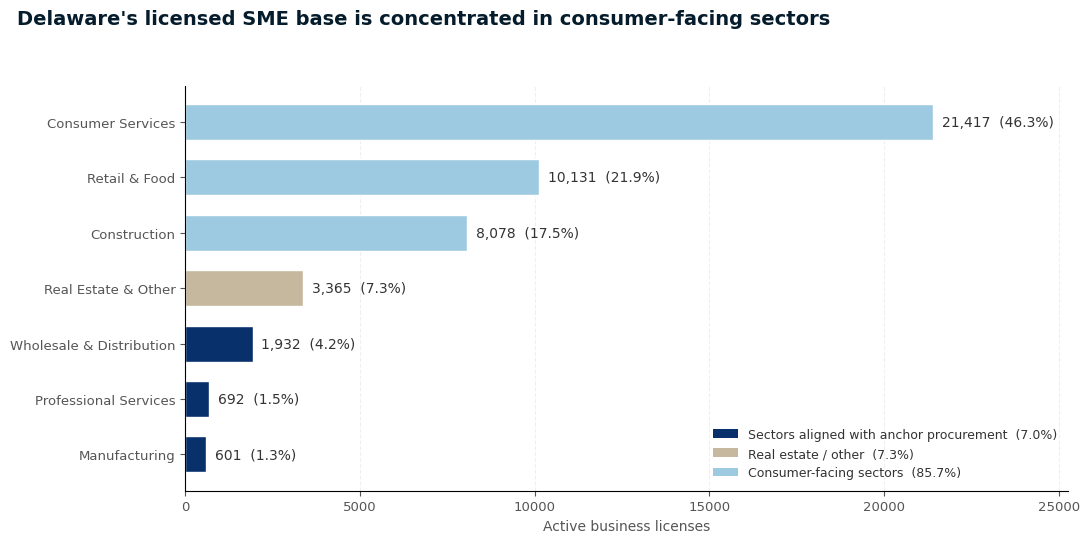

In [29]:
# --- Fig 01: H3 Sector Concentration (with anchor-procurement buckets) ----
# NOTE: Make sure the SECTOR_MAP dictionary from notebook 2.0 is defined
# above this cell (or imported). It contains the 80-key mapping from
# Business Activity values to one of 7 sectors.

df_lic["sector"] = df_lic["Business Activity"].map(SECTOR_MAP).fillna("Unmapped")
sector_counts = df_lic["sector"].value_counts()
sector_share = (sector_counts / len(df_lic) * 100).round(1)

# Bucket each sector into one of three groups
BUCKET = {
    "Consumer Services":         "Consumer-facing",
    "Retail & Food":             "Consumer-facing",
    "Construction":              "Consumer-facing",
    "Real Estate & Other":       "Neutral",
    "Wholesale & Distribution":  "Value-chain-aligned",
    "Professional Services":     "Value-chain-aligned",
    "Manufacturing":             "Value-chain-aligned",
}

BUCKET_COLOR = {
    "Consumer-facing":     STYLE["blue_light"],   # #9ECAE1
    "Neutral":             "#C5B89F",              # warm gray, local
    "Value-chain-aligned": STYLE["blue_darkest"],  # #08306B
}

# --- Compute bucket totals for the legend --------------------------------
bucket_totals = {}
for sector, count in sector_counts.items():
    bucket = BUCKET[sector]
    bucket_totals[bucket] = bucket_totals.get(bucket, 0) + count

bucket_shares = {k: v / len(df_lic) * 100 for k, v in bucket_totals.items()}

# --- Build chart ---------------------------------------------------------
order_asc = sector_counts.sort_values(ascending=True).index.tolist()
counts_asc = sector_counts[order_asc].values
shares_asc = sector_share[order_asc].values
colors_asc = [BUCKET_COLOR[BUCKET[s]] for s in order_asc]

fig, ax = plt.subplots(figsize=FIG_WIDE)

bars = ax.barh(order_asc, counts_asc, color=colors_asc,
               edgecolor="white", height=0.65)

for bar, cnt, pct in zip(bars, counts_asc, shares_asc):
    ax.text(bar.get_width() + 250,
            bar.get_y() + bar.get_height()/2,
            f"{cnt:,}  ({pct}%)",
            va="center", fontsize=ANNOTATION_SIZE, color=STYLE["body"])

# Title only (no subtitle) — set directly on the figure
fig.suptitle(
    "Delaware's licensed SME base is concentrated in consumer-facing sectors",
    fontsize=TITLE_SIZE, fontweight="bold",
    x=0.02, y=0.98, ha="left", color=STYLE["navy"],
)

ax.set_xlabel("Active business licenses",
              fontsize=AXIS_LABEL_SIZE, color=STYLE["muted"])
ax.set_xlim(0, counts_asc.max() * 1.18)
apply_standard_axes(ax, show_ygrid=False, show_xgrid=True)

# Legend explaining what the colors mean
legend_elements = [
    Patch(facecolor=BUCKET_COLOR["Value-chain-aligned"],
          label=f"Sectors aligned with anchor procurement  ({bucket_shares['Value-chain-aligned']:.1f}%)"),
    Patch(facecolor=BUCKET_COLOR["Neutral"],
          label=f"Real estate / other  ({bucket_shares['Neutral']:.1f}%)"),
    Patch(facecolor=BUCKET_COLOR["Consumer-facing"],
          label=f"Consumer-facing sectors  ({bucket_shares['Consumer-facing']:.1f}%)"),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=False,
          fontsize=9, labelcolor=STYLE["body"])

plt.tight_layout(rect=[0, 0, 1, 0.93])

out = DECK_FIGURES / "fig01_sector_concentration.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/fig02_spending_trajectory.png


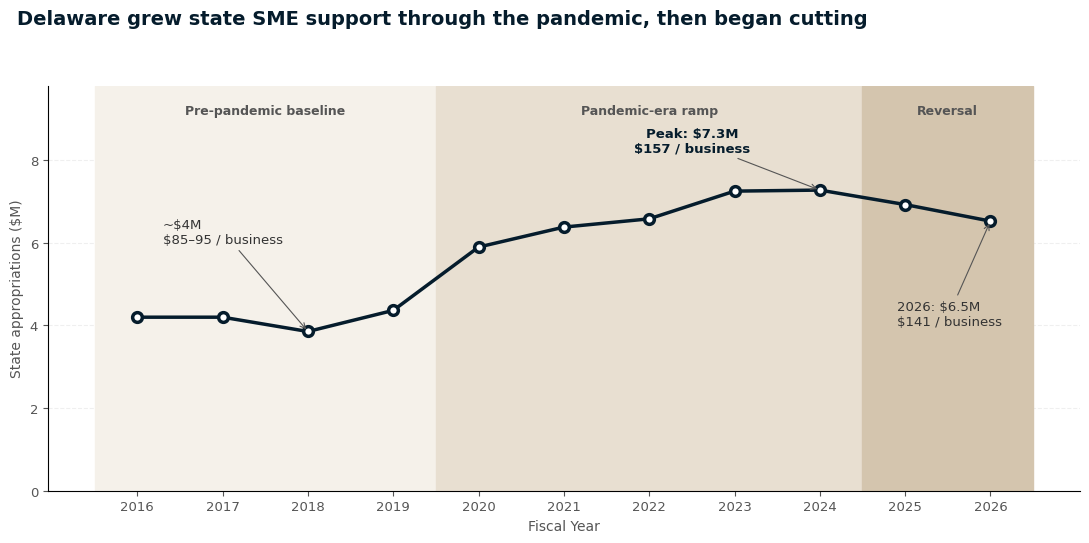

In [23]:
# --- Fig 02: H5 Spending Trajectory ---------------------------------------

# Recompute the SME filter and annual series (local to this cell)
TARGETED_SME = [
    "DE Small Business Dev Ctr", "Business Incubators", "Angel Investor",
    "Blue Collar", "Main Street", "DE Business Marketing Pgm",
    "Financial Development Operations", "Private Business and Trade School",
    "Eastern Trade Council", "International Trade of DE", "World Trade Center Delaware",
    "International Trade", "Tobacco: Innovation Fund", "Health Care Innovation",
    "Workforce Development", "Agriculture Development Program",
    "Interstate Agric Commission", "Agriculture Advertising",
    "Alternative Agriculture Projects",
]
N_BUSINESSES = 46216

targeted_bud = df_bud[df_bud["Appropriation"].isin(TARGETED_SME)].copy()
annual = (
    targeted_bud.groupby("Fiscal Year")["Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Amount": "spend_k"})
)
annual["spend_m"] = annual["spend_k"] * 1000 / 1_000_000
annual["per_business"] = annual["spend_k"] * 1000 / N_BUSINESSES

# --- Build chart ----------------------------------------------------------
fig, ax = plt.subplots(figsize=FIG_WIDE)

# Three-era shading with warm neutrals
ax.axvspan(2015.5, 2019.5, alpha=1.0, color=STYLE["neutral_pale"])
ax.axvspan(2019.5, 2024.5, alpha=1.0, color=STYLE["neutral_mid"])
ax.axvspan(2024.5, 2026.5, alpha=1.0, color=STYLE["neutral_deep"])

# Data line
ax.plot(annual["Fiscal Year"], annual["spend_m"],
        color=STYLE["navy"], linewidth=2.5, marker="o", markersize=7,
        markerfacecolor="white", markeredgewidth=2.5)

# Era labels along the top, discreetly
era_y = 9.1
ax.text(2017.5, era_y, "Pre-pandemic baseline", ha="center",
        fontsize=9, color=STYLE["muted"], fontweight="bold")
ax.text(2022, era_y, "Pandemic-era ramp", ha="center",
        fontsize=9, color=STYLE["muted"], fontweight="bold")
ax.text(2025.5, era_y, "Reversal", ha="center",
        fontsize=9, color=STYLE["muted"], fontweight="bold")

# Reference points for annotations
peak_val = annual.loc[annual["Fiscal Year"] == 2024, "spend_m"].values[0]
curr_val = annual.loc[annual["Fiscal Year"] == 2026, "spend_m"].values[0]
base_val = annual.loc[annual["Fiscal Year"] == 2018, "spend_m"].values[0]

ax.annotate("~$4M\n$85–95 / business",
            xy=(2018, base_val), xytext=(2016.3, 6.0),
            fontsize=9.5, ha="left", color=STYLE["body"],
            arrowprops=dict(arrowstyle="->", color=STYLE["muted"], lw=0.8))

ax.annotate("Peak: $7.3M\n$157 / business",
            xy=(2024, peak_val), xytext=(2022.5, 8.2),
            fontsize=9.5, ha="center", color=STYLE["navy"], fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=STYLE["muted"], lw=0.8))

ax.annotate("2026: $6.5M\n$141 / business",
            xy=(2026, curr_val), xytext=(2024.9, 4.0),
            fontsize=9.5, ha="left", color=STYLE["body"],
            arrowprops=dict(arrowstyle="->", color=STYLE["muted"], lw=0.8))

# Title only (no subtitle) — set directly on the figure
fig.suptitle(
    "Delaware grew state SME support through the pandemic, then began cutting",
    fontsize=TITLE_SIZE, fontweight="bold",
    x=0.02, y=0.98, ha="left", color=STYLE["navy"],
)

ax.set_xlabel("Fiscal Year", fontsize=AXIS_LABEL_SIZE, color=STYLE["muted"])
ax.set_ylabel("State appropriations ($M)", fontsize=AXIS_LABEL_SIZE, color=STYLE["muted"])
ax.set_xticks(annual["Fiscal Year"])
ax.set_ylim(0, 9.8)
apply_standard_axes(ax, show_ygrid=True, show_xgrid=False)

plt.tight_layout(rect=[0, 0, 1, 0.93])

out = DECK_FIGURES / "fig02_spending_trajectory.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/fig03_quadrant_distance.png


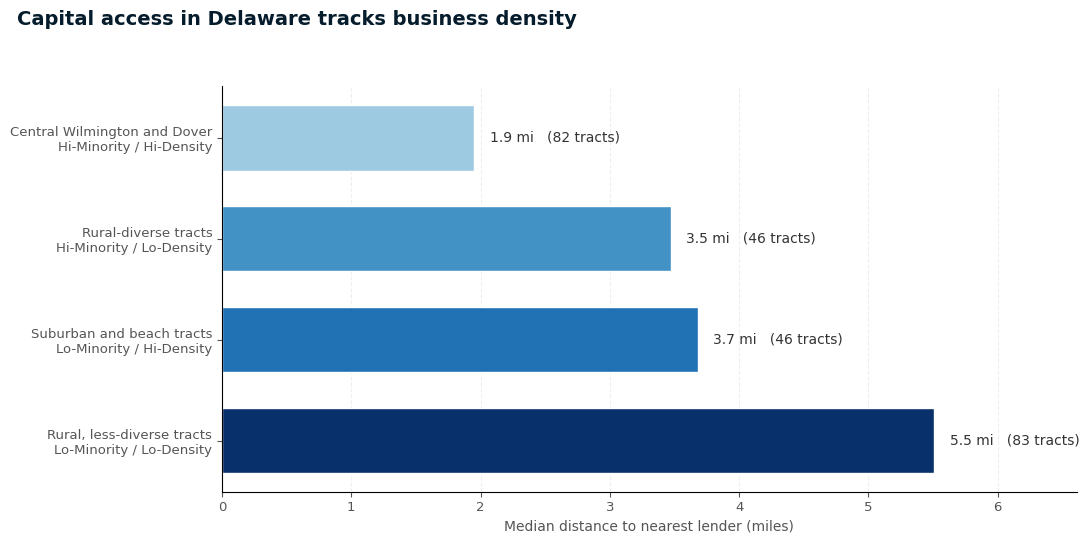

In [25]:
# --- Fig 03: H1 Quadrant Distance Comparison ------------------------------

# Recompute the H1 quadrant data (local to this cell, self-contained)
# Load ACS demographics
acs = pd.read_csv(config.CENSUS_RAW, low_memory=False, skiprows=[1])
acs = acs[["GEO_ID", "NAME", "DP05_0001E", "DP05_0096E"]].rename(columns={
    "DP05_0001E": "pop_total", "DP05_0096E": "pop_white_nh",
})
acs = acs[acs["GEO_ID"].str.startswith("1400000US")].copy()
acs["GEOID"] = acs["GEO_ID"].str[9:]
for col in ["pop_total", "pop_white_nh"]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")
acs["minority_share"] = 1 - (acs["pop_white_nh"] / acs["pop_total"])

# Merge with tracts
tracts_demo = tracts.merge(acs[["GEOID", "pop_total", "minority_share"]],
                           on="GEOID", how="left")
COUNTY_FIPS = {"001": "Kent", "003": "New Castle", "005": "Sussex"}
tracts_demo["county"] = tracts_demo["COUNTYFP"].map(COUNTY_FIPS)
tracts_demo["is_populated"] = tracts_demo["pop_total"] > 0

# Recompute license per tract (via spatial join)
import re
pattern = r"\(([\-\d\.]+),\s*([\-\d\.]+)\)"
coords = df_lic["Geocoded Location"].str.extract(pattern)
df_lic["lat"] = pd.to_numeric(coords[0], errors="coerce")
df_lic["lon"] = pd.to_numeric(coords[1], errors="coerce")
lic_geo = df_lic[
    df_lic["lat"].between(38.4, 39.9) & df_lic["lon"].between(-75.8, -74.9)
].copy()

lic_gdf = gpd.GeoDataFrame(
    lic_geo,
    geometry=gpd.points_from_xy(lic_geo["lon"], lic_geo["lat"]),
    crs="EPSG:4269",
)
joined = gpd.sjoin(lic_gdf, tracts_demo[["GEOID", "geometry"]],
                   how="left", predicate="within")
lic_per_tract = (
    joined[joined["GEOID"].notna()]
    .groupby("GEOID").size().rename("license_count").reset_index()
)
tracts_demo = tracts_demo.merge(lic_per_tract, on="GEOID", how="left")
tracts_demo["license_count"] = tracts_demo["license_count"].fillna(0).astype(int)
tracts_demo["land_sqmi"] = tracts_demo["ALAND"] / 2_589_988
tracts_demo["licenses_per_sqmi"] = tracts_demo["license_count"] / tracts_demo["land_sqmi"]

# Compute distances
UTM_CRS = "EPSG:32618"
tracts_utm = tracts_demo.to_crs(UTM_CRS)
lenders_gdf = gpd.GeoDataFrame(
    lenders,
    geometry=gpd.points_from_xy(lenders["longitude"], lenders["latitude"]),
    crs="EPSG:4269",
).to_crs(UTM_CRS)

tract_centroids = tracts_utm.geometry.centroid
distances_m = [lenders_gdf.geometry.distance(c).min() for c in tract_centroids]
tracts_demo["nearest_lender_mi"] = [d / 1609.34 for d in distances_m]

# Assign quadrants
pop = tracts_demo[tracts_demo["is_populated"]].copy()
min_med = pop["minority_share"].median()
den_med = pop["licenses_per_sqmi"].median()

def assign_quadrant(row):
    hi_min = row["minority_share"] > min_med
    hi_den = row["licenses_per_sqmi"] > den_med
    if hi_min and hi_den:       return "Hi-Minority / Hi-Density"
    if hi_min and not hi_den:   return "Hi-Minority / Lo-Density"
    if not hi_min and hi_den:   return "Lo-Minority / Hi-Density"
    return "Lo-Minority / Lo-Density"

pop["quadrant"] = pop.apply(assign_quadrant, axis=1)

quad_stats = (
    pop.groupby("quadrant")
    .agg(n_tracts=("GEOID", "count"),
         median_distance_mi=("nearest_lender_mi", "median"))
    .round(2)
)

# --- Build chart ----------------------------------------------------------
# Order worst-to-best, with interpretive labels
quad_order = [
    "Lo-Minority / Lo-Density",
    "Lo-Minority / Hi-Density",
    "Hi-Minority / Lo-Density",
    "Hi-Minority / Hi-Density",
]
interpretive_labels = [
    "Rural, less-diverse tracts\nLo-Minority / Lo-Density",
    "Suburban and beach tracts\nLo-Minority / Hi-Density",
    "Rural-diverse tracts\nHi-Minority / Lo-Density",
    "Central Wilmington and Dover\nHi-Minority / Hi-Density",
]

chart_data = quad_stats.loc[quad_order].copy()

# Sequential blue darkest-to-palest (worst gets darkest)
colors = [STYLE["blue_darkest"], STYLE["blue_dark"],
          STYLE["blue_mid"], STYLE["blue_light"]]

fig, ax = plt.subplots(figsize=FIG_WIDE)

bars = ax.barh(interpretive_labels, chart_data["median_distance_mi"],
               color=colors, edgecolor="white", height=0.65)

for bar, dist, n in zip(bars, chart_data["median_distance_mi"],
                         chart_data["n_tracts"]):
    ax.text(bar.get_width() + 0.12,
            bar.get_y() + bar.get_height()/2,
            f"{dist:.1f} mi   ({n} tracts)",
            va="center", fontsize=ANNOTATION_SIZE, color=STYLE["body"])

# Title only (no subtitle) — set directly on the figure
fig.suptitle(
    "Capital access in Delaware tracks business density",
    fontsize=TITLE_SIZE, fontweight="bold",
    x=0.02, y=0.98, ha="left", color=STYLE["navy"],
)

ax.set_xlabel("Median distance to nearest lender (miles)",
              fontsize=AXIS_LABEL_SIZE, color=STYLE["muted"])
ax.set_xlim(0, chart_data["median_distance_mi"].max() * 1.2)
apply_standard_axes(ax, show_ygrid=False, show_xgrid=True)

plt.tight_layout(rect=[0, 0, 1, 0.93])

out = DECK_FIGURES / "fig03_quadrant_distance.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/fig04_lender_distance_map.png


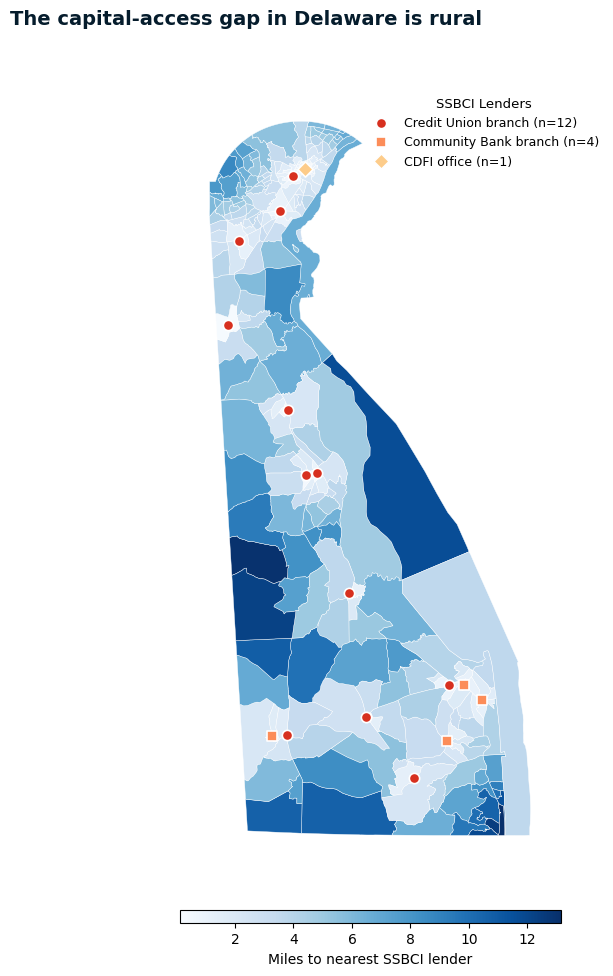

In [26]:
# --- Fig 04: H1 Choropleth Map of Lender Distance -------------------------
# Uses `tracts_demo` and `lenders_gdf` from cell 5. Run that cell first.

fig, ax = plt.subplots(figsize=(9, 11))

# Base choropleth — tracts shaded by distance to nearest lender
# Sequential Blues: lighter = close, darker = far
tracts_demo.plot(
    column="nearest_lender_mi",
    cmap="Blues",
    linewidth=0.3,
    edgecolor="white",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Miles to nearest SSBCI lender",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.04,
        "aspect": 30,
    },
    missing_kwds={"color": "#e8e8e8", "edgecolor": "white"},
)

# Overlay lender branches — convert back to lat/lon for plotting
lenders_plot = lenders_gdf.to_crs("EPSG:4269")

type_styles = {
    "Credit Union":   {"marker": "o", "color": STYLE["accent_red"],    "size": 55, "label": "Credit Union branch"},
    "Community Bank": {"marker": "s", "color": STYLE["accent_orange"], "size": 50, "label": "Community Bank branch"},
    "CDFI":           {"marker": "D", "color": STYLE["accent_tan"],    "size": 60, "label": "CDFI office"},
}
for inst_type, style in type_styles.items():
    subset = lenders_plot[lenders_plot["institution_type"] == inst_type]
    n = len(subset)
    ax.scatter(
        subset.geometry.x, subset.geometry.y,
        marker=style["marker"],
        s=style["size"],
        color=style["color"],
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
        label=f"{style['label']} (n={n})",
    )

# Title only (no subtitle)
fig.suptitle(
    "The capital-access gap in Delaware is rural",
    fontsize=TITLE_SIZE, fontweight="bold", x=0.04, y=0.965, ha="left",
    color=STYLE["navy"],
)

# Clean up map aesthetics
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend for lender markers (separate from the colorbar)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.18, 1.0),
    frameon=False,
    fontsize=9,
    title="SSBCI Lenders",
    title_fontsize=9.5,
)

# Reserve right-edge space so the legend doesn't clip
plt.tight_layout(rect=[0, 0, 0.88, 0.94])

out = DECK_FIGURES / "fig04_lender_distance_map.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/fig05_program_mix_appendix.png


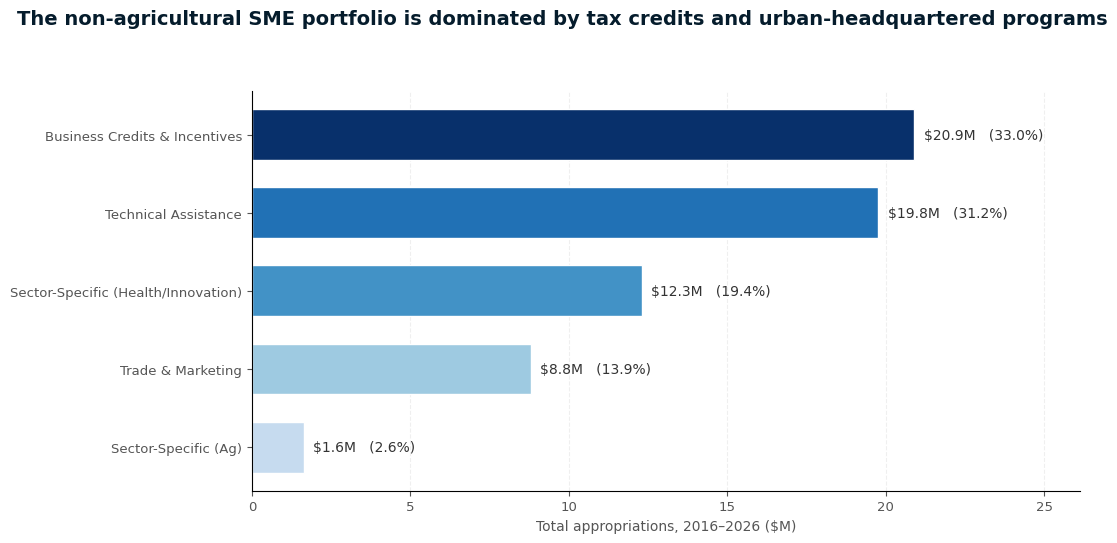

In [27]:
# --- Fig 05: H5 Program Mix (Appendix) ------------------------------------

# Program-type classification (19 targeted appropriations → 5 program types)
PROGRAM_TYPE = {
    "DE Small Business Dev Ctr":          "Technical Assistance",
    "Business Incubators":                "Technical Assistance",
    "Workforce Development":              "Technical Assistance",
    "Financial Development Operations":   "Technical Assistance",
    "Private Business and Trade School":  "Technical Assistance",

    "Eastern Trade Council":              "Trade & Marketing",
    "International Trade of DE":          "Trade & Marketing",
    "World Trade Center Delaware":        "Trade & Marketing",
    "International Trade":                "Trade & Marketing",
    "DE Business Marketing Pgm":          "Trade & Marketing",
    "Main Street":                        "Trade & Marketing",

    "Blue Collar":                        "Business Credits & Incentives",
    "Angel Investor":                     "Business Credits & Incentives",

    "Agriculture Development Program":    "Sector-Specific (Ag)",
    "Interstate Agric Commission":        "Sector-Specific (Ag)",
    "Agriculture Advertising":            "Sector-Specific (Ag)",
    "Alternative Agriculture Projects":   "Sector-Specific (Ag)",

    "Tobacco: Innovation Fund":           "Sector-Specific (Health/Innovation)",
    "Health Care Innovation":             "Sector-Specific (Health/Innovation)",
}

targeted_bud["program_type"] = targeted_bud["Appropriation"].map(PROGRAM_TYPE)

mix = (
    targeted_bud.groupby("program_type")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
mix["dollars"] = mix["Amount"] * 1000
mix["share"] = mix["dollars"] / mix["dollars"].sum() * 100

# --- Build chart ----------------------------------------------------------
mix_asc = mix.sort_values("dollars", ascending=True)

# Sequential blue: darkest at top (largest share)
# Since ordered ascending, index 0 is smallest -> palest
palette = [STYLE["blue_palest"], STYLE["blue_light"], STYLE["blue_mid"],
           STYLE["blue_dark"], STYLE["blue_darkest"]]
bar_colors = palette[:len(mix_asc)]

fig, ax = plt.subplots(figsize=FIG_WIDE)

bars = ax.barh(mix_asc["program_type"], mix_asc["dollars"] / 1_000_000,
               color=bar_colors, edgecolor="white", height=0.65)

for bar, dollars, share in zip(bars, mix_asc["dollars"], mix_asc["share"]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"${dollars/1_000_000:.1f}M   ({share:.1f}%)",
            va="center", fontsize=ANNOTATION_SIZE, color=STYLE["body"])

# Title only (no subtitle) — set directly on the figure
fig.suptitle(
    "The non-agricultural SME portfolio is dominated by tax credits and urban-headquartered programs",
    fontsize=TITLE_SIZE, fontweight="bold",
    x=0.02, y=0.98, ha="left", color=STYLE["navy"],
)

ax.set_xlabel("Total appropriations, 2016–2026 ($M)",
              fontsize=AXIS_LABEL_SIZE, color=STYLE["muted"])
ax.set_xlim(0, mix["dollars"].max() / 1_000_000 * 1.25)
apply_standard_axes(ax, show_ygrid=False, show_xgrid=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])

out = DECK_FIGURES / "fig05_program_mix_appendix.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## Outputs

Five figures saved to `reports/figures/`:

| File | Role | Used in |
|---|---|---|
| `fig01_sector_concentration.png` | Hero | H3 finding — industry composition |
| `fig02_spending_trajectory.png` | Hero | H5 finding — budget trajectory |
| `fig03_quadrant_distance.png` | Hero | H1 finding — distance tracks density, not race |
| `fig04_lender_distance_map.png` | Hero | H1 geographic evidence |
| `fig05_program_mix_appendix.png` | Appendix | H5 bifurcation evidence |

All figures use a consistent visual system:
- Palette: sequential blue (data) + warm neutrals (background/context) + warm accents (map markers only)
- Typography: bold navy headline + muted subtitle with sample size / scope context
- No red/green or categorical color coding that implies good/bad judgments
- Consistent axis treatment, gridline color, and annotation color across all charts

These are the files the deck will import directly. Any future revisions to the deliverable charts happen in this notebook only — the hypothesis notebooks (2.0, 2.1, 2.2) remain unchanged as the analytical record.

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/dashboard_01_pipeline.png


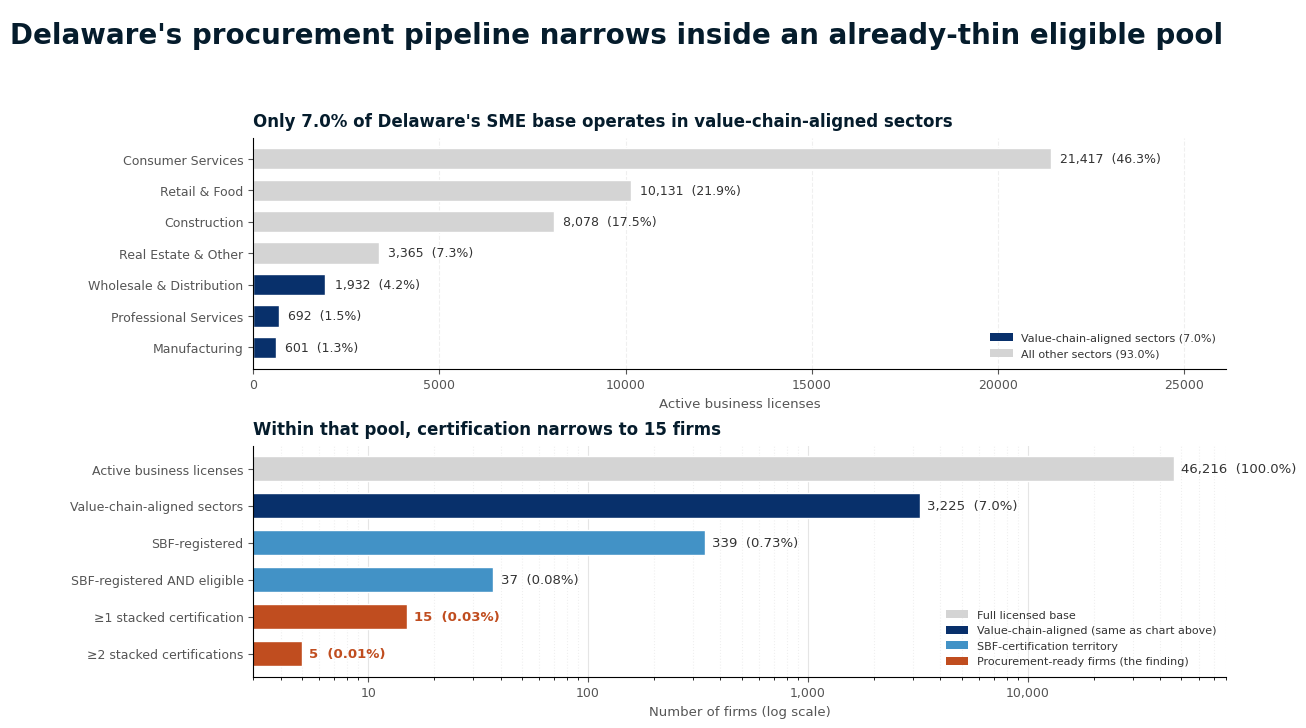

In [37]:
# --- Dashboard 01: The Pipeline Story (set-accurate color coding) --------

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

FIG_W, FIG_H = 13.33, 7.5

# ------ COLOR SYSTEM (encodes set relationships) -------------------------
C_NOT_FOCAL    = "#D4D4D4"   # gray — not the focus (includes Real Estate & Other)
C_FOCAL        = "#08306B"   # navy — the 3 value-chain-aligned sectors
C_INTERMEDIATE = "#4292C6"   # medium blue — SBF territory (related but distinct)
C_FINDING      = "#C04D1F"   # burnt orange — the procurement-ready finding

SLIDE_TITLE = "Delaware's procurement pipeline narrows inside an already-thin eligible pool"

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = fig.add_gridspec(
    nrows=3, ncols=1,
    height_ratios=[0.10, 0.45, 0.45],   # shrunk title band (no takeaway), bigger charts
    left=0.22, right=0.95,
    top=0.96, bottom=0.07,
    hspace=0.45,
)

# ------ Title band (title only, no takeaway) -----------------------------
ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis("off")
ax_title.text(
    -0.25, 0.5, SLIDE_TITLE,
    fontsize=20, fontweight="bold", color=STYLE["navy"],
    ha="left", va="center", transform=ax_title.transAxes,
)

# =========================================================================
# TOP: H3 Sector Concentration
# =========================================================================
ax_top = fig.add_subplot(gs[1, 0])

df_lic["sector"] = df_lic["Business Activity"].map(SECTOR_MAP).fillna("Unmapped")
sector_counts = df_lic["sector"].value_counts()
sector_share = (sector_counts / len(df_lic) * 100).round(1)

# All sectors that are NOT value-chain-aligned collapse into "Not focal"
# (Consumer Services, Retail, Construction, Real Estate & Other → all gray)
BUCKET = {
    "Consumer Services":         "Not focal",
    "Retail & Food":             "Not focal",
    "Construction":              "Not focal",
    "Real Estate & Other":       "Not focal",
    "Wholesale & Distribution":  "Value-chain-aligned",
    "Professional Services":     "Value-chain-aligned",
    "Manufacturing":             "Value-chain-aligned",
}
BUCKET_COLOR = {
    "Not focal":           C_NOT_FOCAL,
    "Value-chain-aligned": C_FOCAL,
}

order_asc = sector_counts.sort_values(ascending=True).index.tolist()
counts_asc = sector_counts[order_asc].values
shares_asc = sector_share[order_asc].values
colors_asc = [BUCKET_COLOR[BUCKET[s]] for s in order_asc]

bars_top = ax_top.barh(order_asc, counts_asc, color=colors_asc,
                        edgecolor="white", height=0.68)

for bar, cnt, pct in zip(bars_top, counts_asc, shares_asc):
    ax_top.text(bar.get_width() + 250,
                bar.get_y() + bar.get_height()/2,
                f"{cnt:,}  ({pct}%)",
                va="center", fontsize=9, color=STYLE["body"])

ax_top.set_title(
    "Only 7.0% of Delaware's SME base operates in value-chain-aligned sectors",
    fontsize=12, fontweight="bold", color=STYLE["navy"],
    loc="left", pad=8,
)
ax_top.set_xlabel("Active business licenses", fontsize=9.5, color=STYLE["muted"])
ax_top.set_xlim(0, counts_asc.max() * 1.22)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.grid(axis="x", linestyle="--", alpha=0.3, color="#CCCCCC")
ax_top.set_axisbelow(True)
ax_top.tick_params(axis="both", labelsize=9, colors=STYLE["muted"])

# Compute bucket shares for legend
bucket_totals = {}
for sector, count in sector_counts.items():
    bucket_totals[BUCKET[sector]] = bucket_totals.get(BUCKET[sector], 0) + count
bucket_shares = {k: v / len(df_lic) * 100 for k, v in bucket_totals.items()}

legend_top = [
    Patch(facecolor=C_FOCAL,
          label=f"Value-chain-aligned sectors ({bucket_shares['Value-chain-aligned']:.1f}%)"),
    Patch(facecolor=C_NOT_FOCAL,
          label=f"All other sectors ({bucket_shares['Not focal']:.1f}%)"),
]
ax_top.legend(handles=legend_top, loc="lower right", frameon=False,
              fontsize=8, labelcolor=STYLE["body"])

# =========================================================================
# BOTTOM: SBF Funnel
# =========================================================================
ax_bot = fig.add_subplot(gs[2, 0])

stages = [
    ("Active business licenses",        46216, "base"),          # gray
    ("Value-chain-aligned sectors",      3225, "focal"),         # navy — matches chart 1
    ("SBF-registered",                    339, "intermediate"),  # medium blue — different set
    ("SBF-registered AND eligible",        37, "intermediate"),  # medium blue — intersection
    ("≥1 stacked certification",           15, "finding"),       # burnt orange — the finding
    ("≥2 stacked certifications",           5, "finding"),       # burnt orange — the finding
]

color_map = {
    "base":         C_NOT_FOCAL,
    "focal":        C_FOCAL,
    "intermediate": C_INTERMEDIATE,
    "finding":      C_FINDING,
}

labels = [s[0] for s in stages]
values = [s[1] for s in stages]
roles = [s[2] for s in stages]
bar_colors = [color_map[r] for r in roles]

y_pos = list(range(len(stages)))

bars_bot = ax_bot.barh(y_pos, values, color=bar_colors,
                        edgecolor="white", height=0.68)

for bar, val, role in zip(bars_bot, values, roles):
    share = val / values[0] * 100
    label_text = f"{val:,}  ({share:.2f}%)" if val < 1000 else f"{val:,}  ({share:.1f}%)"
    weight = "bold" if role == "finding" else "normal"
    text_color = C_FINDING if role == "finding" else STYLE["body"]
    ax_bot.text(bar.get_width() * 1.08,
                bar.get_y() + bar.get_height()/2,
                label_text,
                va="center", fontsize=9.5, color=text_color, fontweight=weight)

ax_bot.set_yticks(y_pos)
ax_bot.set_yticklabels(labels, fontsize=9.5)
ax_bot.invert_yaxis()

ax_bot.set_xscale("log")
ax_bot.set_xlim(3, 80000)

def plain_number(x, pos):
    if x >= 1:
        return f"{int(x):,}"
    return str(x)

ax_bot.xaxis.set_major_formatter(FuncFormatter(plain_number))
ax_bot.grid(axis="x", which="major", linestyle="-", alpha=0.25, color="#999999")
ax_bot.grid(axis="x", which="minor", linestyle=":", alpha=0.15, color="#999999")
ax_bot.set_axisbelow(True)

ax_bot.set_title(
    "Within that pool, certification narrows to 15 firms",
    fontsize=12, fontweight="bold", color=STYLE["navy"],
    loc="left", pad=8,
)
ax_bot.set_xlabel("Number of firms (log scale)", fontsize=9.5, color=STYLE["muted"])
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)
ax_bot.tick_params(axis="both", labelsize=9, colors=STYLE["muted"])

legend_bot = [
    Patch(facecolor=C_NOT_FOCAL,    label="Full licensed base"),
    Patch(facecolor=C_FOCAL,        label="Value-chain-aligned (same as chart above)"),
    Patch(facecolor=C_INTERMEDIATE, label="SBF-certification territory"),
    Patch(facecolor=C_FINDING,      label="Procurement-ready firms (the finding)"),
]
ax_bot.legend(handles=legend_bot, loc="lower right", frameon=False,
              fontsize=8, labelcolor=STYLE["body"])

# ------ SAVE -------------------------------------------------------------
out = DECK_FIGURES / "dashboard_01_pipeline.png"
plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {out}")
plt.show()

/var/folders/yg/p7rwc_8122xgg6kqmd7rm6jc0000gn/T/ipykernel_60291/2134802081.py:132: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues_cmap = cm.get_cmap("Blues")


Saved: /Users/renzo/Documents/DSU_UN/reports/figures/dashboard_02_geography.png


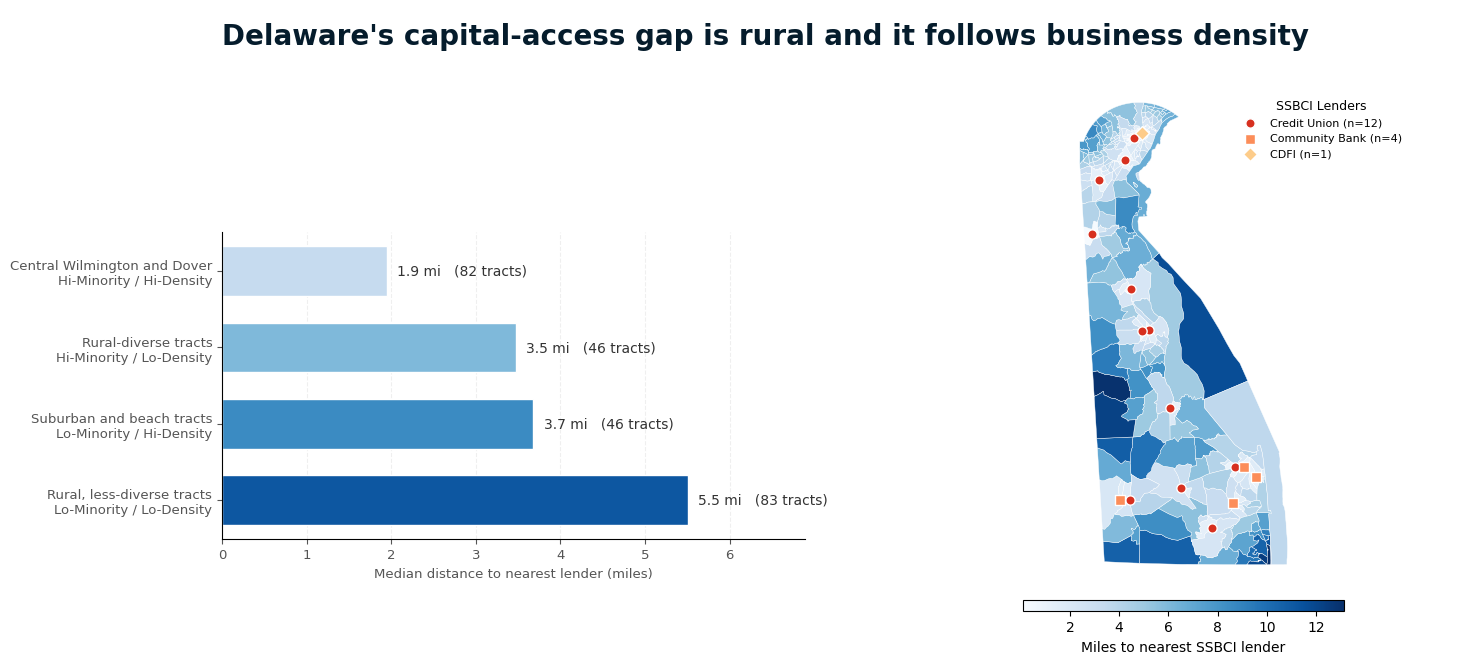

In [43]:
# --- Dashboard 02: The Geography Story (matched color gradient) ----------

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import cm
import geopandas as gpd
import pandas as pd
import re

FIG_W, FIG_H = 13.33, 7.5

SLIDE_TITLE = "Delaware's capital-access gap is rural and it follows business density"

# =========================================================================
# RECOMPUTE H1 DATA (self-contained)
# =========================================================================
acs = pd.read_csv(config.CENSUS_RAW, low_memory=False, skiprows=[1])
acs = acs[["GEO_ID", "NAME", "DP05_0001E", "DP05_0096E"]].rename(columns={
    "DP05_0001E": "pop_total", "DP05_0096E": "pop_white_nh",
})
acs = acs[acs["GEO_ID"].str.startswith("1400000US")].copy()
acs["GEOID"] = acs["GEO_ID"].str[9:]
for col in ["pop_total", "pop_white_nh"]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")
acs["minority_share"] = 1 - (acs["pop_white_nh"] / acs["pop_total"])

tracts_demo = tracts.merge(acs[["GEOID", "pop_total", "minority_share"]],
                           on="GEOID", how="left")
tracts_demo["is_populated"] = tracts_demo["pop_total"] > 0

pattern = r"\(([\-\d\.]+),\s*([\-\d\.]+)\)"
coords = df_lic["Geocoded Location"].str.extract(pattern)
df_lic["lat"] = pd.to_numeric(coords[0], errors="coerce")
df_lic["lon"] = pd.to_numeric(coords[1], errors="coerce")
lic_geo = df_lic[
    df_lic["lat"].between(38.4, 39.9) & df_lic["lon"].between(-75.8, -74.9)
].copy()
lic_gdf = gpd.GeoDataFrame(
    lic_geo, geometry=gpd.points_from_xy(lic_geo["lon"], lic_geo["lat"]),
    crs="EPSG:4269",
)
joined = gpd.sjoin(lic_gdf, tracts_demo[["GEOID", "geometry"]],
                   how="left", predicate="within")
lic_per_tract = (
    joined[joined["GEOID"].notna()]
    .groupby("GEOID").size().rename("license_count").reset_index()
)
tracts_demo = tracts_demo.merge(lic_per_tract, on="GEOID", how="left")
tracts_demo["license_count"] = tracts_demo["license_count"].fillna(0).astype(int)
tracts_demo["land_sqmi"] = tracts_demo["ALAND"] / 2_589_988
tracts_demo["licenses_per_sqmi"] = tracts_demo["license_count"] / tracts_demo["land_sqmi"]

UTM_CRS = "EPSG:32618"
tracts_utm = tracts_demo.to_crs(UTM_CRS)
lenders_gdf = gpd.GeoDataFrame(
    lenders, geometry=gpd.points_from_xy(lenders["longitude"], lenders["latitude"]),
    crs="EPSG:4269",
).to_crs(UTM_CRS)
tract_centroids = tracts_utm.geometry.centroid
distances_m = [lenders_gdf.geometry.distance(c).min() for c in tract_centroids]
tracts_demo["nearest_lender_mi"] = [d / 1609.34 for d in distances_m]

pop = tracts_demo[tracts_demo["is_populated"]].copy()
min_med = pop["minority_share"].median()
den_med = pop["licenses_per_sqmi"].median()

def assign_quadrant(row):
    hi_min = row["minority_share"] > min_med
    hi_den = row["licenses_per_sqmi"] > den_med
    if hi_min and hi_den:     return "Hi-Minority / Hi-Density"
    if hi_min and not hi_den: return "Hi-Minority / Lo-Density"
    if not hi_min and hi_den: return "Lo-Minority / Hi-Density"
    return "Lo-Minority / Lo-Density"

pop["quadrant"] = pop.apply(assign_quadrant, axis=1)
quad_stats = (
    pop.groupby("quadrant")
    .agg(n_tracts=("GEOID", "count"),
         median_distance_mi=("nearest_lender_mi", "median"))
    .round(2)
)

# =========================================================================
# BUILD THE DASHBOARD
# =========================================================================
fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    height_ratios=[0.08, 0.92],
    width_ratios=[1.0, 1.0],
    left=0.04, right=0.98,
    top=0.96, bottom=0.05,
    hspace=0.05, wspace=0.15,
)

# ------ Title band -------------------------------------------------------
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis("off")
ax_title.text(
    0.0, 0.5, SLIDE_TITLE,
    fontsize=20, fontweight="bold", color=STYLE["navy"],
    ha="left", va="center", transform=ax_title.transAxes,
)

# =========================================================================
# LEFT: Quadrant bar — colors sampled from the Blues colormap
# =========================================================================
gs_left = gs[1, 0].subgridspec(
    nrows=3, ncols=1,
    height_ratios=[0.25, 0.50, 0.25],
    hspace=0,
)
ax_left = fig.add_subplot(gs_left[1, 0])

quad_order = [
    "Lo-Minority / Lo-Density",
    "Lo-Minority / Hi-Density",
    "Hi-Minority / Lo-Density",
    "Hi-Minority / Hi-Density",
]
interpretive_labels = [
    "Rural, less-diverse tracts\nLo-Minority / Lo-Density",
    "Suburban and beach tracts\nLo-Minority / Hi-Density",
    "Rural-diverse tracts\nHi-Minority / Lo-Density",
    "Central Wilmington and Dover\nHi-Minority / Hi-Density",
]

chart_data = quad_stats.loc[quad_order].copy()

# Sample the same Blues colormap the map uses, at four positions
# ordered dark→pale to match worst→best distance
blues_cmap = cm.get_cmap("Blues")
bar_colors = [blues_cmap(t) for t in [0.85, 0.65, 0.45, 0.25]]

bars_left = ax_left.barh(interpretive_labels, chart_data["median_distance_mi"],
                          color=bar_colors, edgecolor="white", height=0.65)

for bar, dist, n in zip(bars_left,
                         chart_data["median_distance_mi"],
                         chart_data["n_tracts"]):
    ax_left.text(bar.get_width() + 0.12,
                 bar.get_y() + bar.get_height()/2,
                 f"{dist:.1f} mi   ({n} tracts)",
                 va="center", fontsize=10, color=STYLE["body"])

ax_left.set_xlabel("Median distance to nearest lender (miles)",
                    fontsize=9.5, color=STYLE["muted"])
ax_left.set_xlim(0, chart_data["median_distance_mi"].max() * 1.25)
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.grid(axis="x", linestyle="--", alpha=0.3, color="#CCCCCC")
ax_left.set_axisbelow(True)
ax_left.tick_params(axis="both", labelsize=9.5, colors=STYLE["muted"])

# =========================================================================
# RIGHT: Choropleth map (uses Blues colormap)
# =========================================================================
ax_right = fig.add_subplot(gs[1, 1])

tracts_demo.plot(
    column="nearest_lender_mi",
    cmap="Blues",
    linewidth=0.3,
    edgecolor="white",
    ax=ax_right,
    legend=True,
    legend_kwds={
        "label": "Miles to nearest SSBCI lender",
        "orientation": "horizontal",
        "shrink": 0.55,
        "pad": 0.02,
        "aspect": 30,
    },
    missing_kwds={"color": "#e8e8e8", "edgecolor": "white"},
)

# Overlay lender branches
lenders_plot = lenders_gdf.to_crs("EPSG:4269")
type_styles = {
    "Credit Union":   {"marker": "o", "color": STYLE["accent_red"],    "size": 45, "label": "Credit Union"},
    "Community Bank": {"marker": "s", "color": STYLE["accent_orange"], "size": 42, "label": "Community Bank"},
    "CDFI":           {"marker": "D", "color": STYLE["accent_tan"],    "size": 50, "label": "CDFI"},
}
for inst_type, style in type_styles.items():
    subset = lenders_plot[lenders_plot["institution_type"] == inst_type]
    n = len(subset)
    ax_right.scatter(
        subset.geometry.x, subset.geometry.y,
        marker=style["marker"], s=style["size"],
        color=style["color"], edgecolor="white",
        linewidth=1.0, zorder=5,
        label=f"{style['label']} (n={n})",
    )

ax_right.set_xlabel("")
ax_right.set_ylabel("")
ax_right.set_xticks([])
ax_right.set_yticks([])
for spine in ax_right.spines.values():
    spine.set_visible(False)

# Legend shifted right from the upper-left corner
ax_right.legend(
    loc="upper left",
    bbox_to_anchor=(0.7, 0.98),
    frameon=False,
    fontsize=8,
    title="SSBCI Lenders",
    title_fontsize=9,
)



# ------ SAVE -------------------------------------------------------------
out = DECK_FIGURES / "dashboard_02_geography.png"
plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {out}")
plt.show()

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/dashboard_03_funding.png


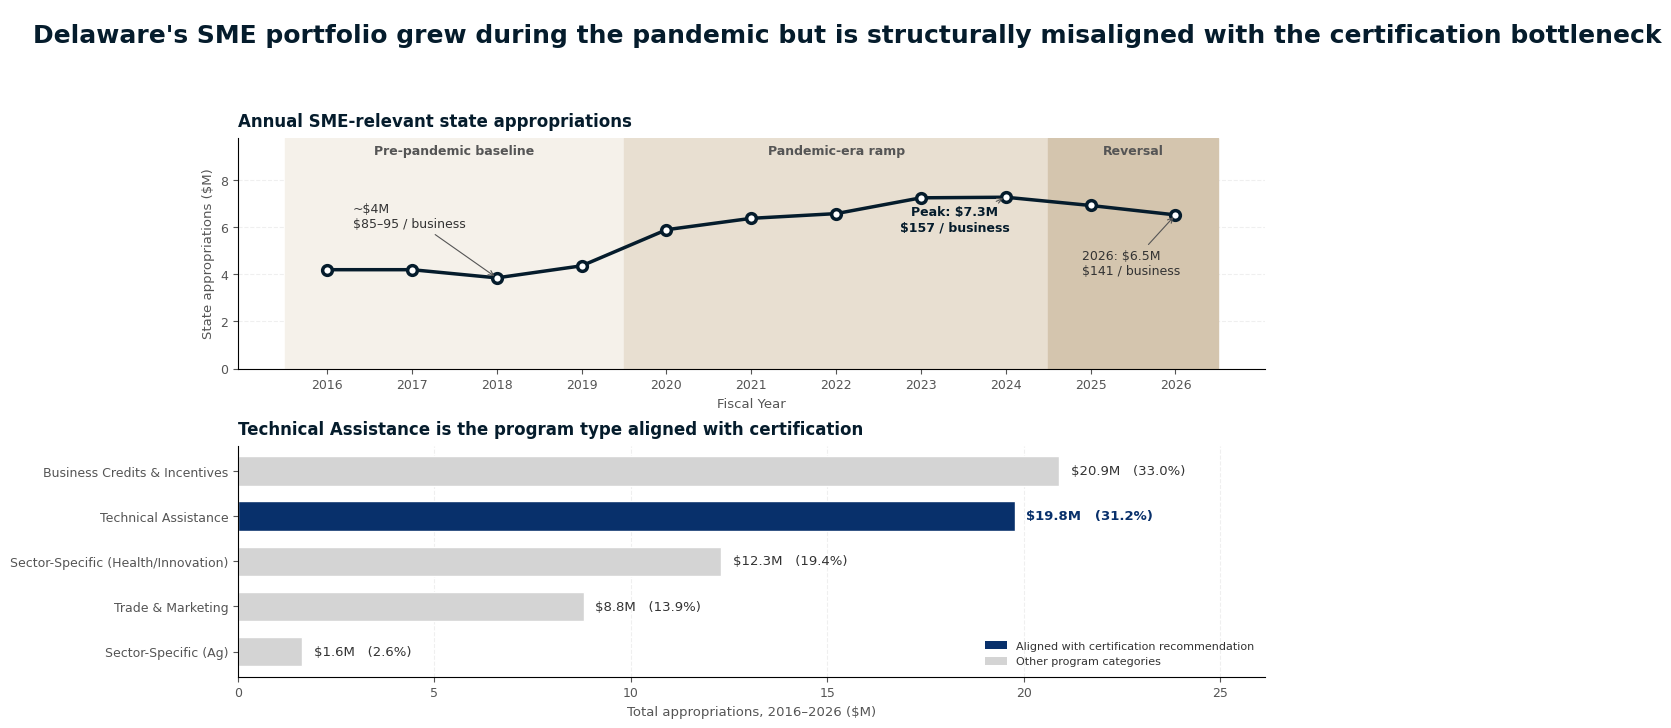

In [48]:
# --- Dashboard 03: The Funding Architecture Story ------------------------
# Top: H5 spending trajectory (time-series with three eras)
# Bottom: H5 program mix (the bifurcation that the certification recommendation
#         needs to reckon with)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FIG_W, FIG_H = 13.33, 7.5

# ------ COLOR SYSTEM (consistent with Dashboards 01 & 02) ----------------
C_NOT_FOCAL = "#D4D4D4"   # gray — not the focus
C_FOCAL     = "#08306B"   # navy — the program type aligned with the recommendation
C_NEUTRAL_PALE = STYLE["neutral_pale"]
C_NEUTRAL_MID  = STYLE["neutral_mid"]
C_NEUTRAL_DEEP = STYLE["neutral_deep"]

SLIDE_TITLE = (
    "Delaware's SME portfolio grew during the pandemic but is structurally "
    "misaligned with the certification bottleneck"
)

# =========================================================================
# RECOMPUTE H5 DATA (self-contained)
# =========================================================================
TARGETED_SME = [
    "DE Small Business Dev Ctr", "Business Incubators", "Angel Investor",
    "Blue Collar", "Main Street", "DE Business Marketing Pgm",
    "Financial Development Operations", "Private Business and Trade School",
    "Eastern Trade Council", "International Trade of DE", "World Trade Center Delaware",
    "International Trade", "Tobacco: Innovation Fund", "Health Care Innovation",
    "Workforce Development", "Agriculture Development Program",
    "Interstate Agric Commission", "Agriculture Advertising",
    "Alternative Agriculture Projects",
]
N_BUSINESSES = 46216

targeted_bud = df_bud[df_bud["Appropriation"].isin(TARGETED_SME)].copy()

# Trajectory series
annual = (
    targeted_bud.groupby("Fiscal Year")["Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Amount": "spend_k"})
)
annual["spend_m"] = annual["spend_k"] * 1000 / 1_000_000
annual["per_business"] = annual["spend_k"] * 1000 / N_BUSINESSES

# Program-mix categories
PROGRAM_TYPE = {
    "DE Small Business Dev Ctr":          "Technical Assistance",
    "Business Incubators":                "Technical Assistance",
    "Workforce Development":              "Technical Assistance",
    "Financial Development Operations":   "Technical Assistance",
    "Private Business and Trade School":  "Technical Assistance",
    "Eastern Trade Council":              "Trade & Marketing",
    "International Trade of DE":          "Trade & Marketing",
    "World Trade Center Delaware":        "Trade & Marketing",
    "International Trade":                "Trade & Marketing",
    "DE Business Marketing Pgm":          "Trade & Marketing",
    "Main Street":                        "Trade & Marketing",
    "Blue Collar":                        "Business Credits & Incentives",
    "Angel Investor":                     "Business Credits & Incentives",
    "Agriculture Development Program":    "Sector-Specific (Ag)",
    "Interstate Agric Commission":        "Sector-Specific (Ag)",
    "Agriculture Advertising":            "Sector-Specific (Ag)",
    "Alternative Agriculture Projects":   "Sector-Specific (Ag)",
    "Tobacco: Innovation Fund":           "Sector-Specific (Health/Innovation)",
    "Health Care Innovation":             "Sector-Specific (Health/Innovation)",
}

targeted_bud["program_type"] = targeted_bud["Appropriation"].map(PROGRAM_TYPE)

mix = (
    targeted_bud.groupby("program_type")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
mix["dollars"] = mix["Amount"] * 1000
mix["share"] = mix["dollars"] / mix["dollars"].sum() * 100

# =========================================================================
# BUILD THE DASHBOARD
# =========================================================================
fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = fig.add_gridspec(
    nrows=3, ncols=1,
    height_ratios=[0.10, 0.45, 0.45],
    left=0.18, right=0.95,
    top=0.96, bottom=0.07,
    hspace=0.45,
)

# ------ Title band -------------------------------------------------------
ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis("off")
ax_title.text(
    -0.20, 0.5, SLIDE_TITLE,
    fontsize=18, fontweight="bold", color=STYLE["navy"],
    ha="left", va="center", transform=ax_title.transAxes,
)

# =========================================================================
# TOP: Spending Trajectory
# =========================================================================
ax_top = fig.add_subplot(gs[1, 0])

# Era shading
ax_top.axvspan(2015.5, 2019.5, alpha=1.0, color=C_NEUTRAL_PALE)
ax_top.axvspan(2019.5, 2024.5, alpha=1.0, color=C_NEUTRAL_MID)
ax_top.axvspan(2024.5, 2026.5, alpha=1.0, color=C_NEUTRAL_DEEP)

# Data line
ax_top.plot(annual["Fiscal Year"], annual["spend_m"],
            color=STYLE["navy"], linewidth=2.5, marker="o", markersize=7,
            markerfacecolor="white", markeredgewidth=2.5)

# Era labels along the top
era_y = 9.1
ax_top.text(2017.5, era_y, "Pre-pandemic baseline", ha="center",
            fontsize=9, color=STYLE["muted"], fontweight="bold")
ax_top.text(2022, era_y, "Pandemic-era ramp", ha="center",
            fontsize=9, color=STYLE["muted"], fontweight="bold")
ax_top.text(2025.5, era_y, "Reversal", ha="center",
            fontsize=9, color=STYLE["muted"], fontweight="bold")

# Reference points
peak_val = annual.loc[annual["Fiscal Year"] == 2024, "spend_m"].values[0]
curr_val = annual.loc[annual["Fiscal Year"] == 2026, "spend_m"].values[0]
base_val = annual.loc[annual["Fiscal Year"] == 2018, "spend_m"].values[0]

ax_top.annotate("~$4M\n$85–95 / business",
                xy=(2018, base_val), xytext=(2016.3, 6.0),
                fontsize=9, ha="left", color=STYLE["body"],
                arrowprops=dict(arrowstyle="->", color=STYLE["muted"], lw=0.8))

ax_top.annotate("Peak: $7.3M\n$157 / business",
                xy=(2024, peak_val), xytext=(2023.4, peak_val - 1.4),
                fontsize=9, ha="center", color=STYLE["navy"], fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=STYLE["muted"], lw=0.8))

ax_top.annotate("2026: $6.5M\n$141 / business",
                xy=(2026, curr_val), xytext=(2024.9, 4.0),
                fontsize=9, ha="left", color=STYLE["body"],
                arrowprops=dict(arrowstyle="->", color=STYLE["muted"], lw=0.8))

ax_top.set_xlabel("Fiscal Year", fontsize=9.5, color=STYLE["muted"])
ax_top.set_ylabel("State appropriations ($M)", fontsize=9.5, color=STYLE["muted"])
ax_top.set_xticks(annual["Fiscal Year"])
ax_top.set_ylim(0, 9.8)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.grid(axis="y", linestyle="--", alpha=0.3, color="#CCCCCC")
ax_top.set_axisbelow(True)
ax_top.tick_params(axis="both", labelsize=9, colors=STYLE["muted"])

ax_top.set_title(
    "Annual SME-relevant state appropriations",
    fontsize=12, fontweight="bold", color=STYLE["navy"],
    loc="left", pad=8,
)

# =========================================================================
# BOTTOM: Program Mix
# =========================================================================
ax_bot = fig.add_subplot(gs[2, 0])

# Sort ascending so largest is at the top after barh
mix_asc = mix.sort_values("dollars", ascending=True)

# Color: navy for Technical Assistance, gray for everything else
bar_colors = [
    C_FOCAL if program == "Technical Assistance" else C_NOT_FOCAL
    for program in mix_asc["program_type"]
]

bars_bot = ax_bot.barh(mix_asc["program_type"], mix_asc["dollars"] / 1_000_000,
                        color=bar_colors, edgecolor="white", height=0.65)

for bar, dollars, share, program in zip(bars_bot,
                                          mix_asc["dollars"],
                                          mix_asc["share"],
                                          mix_asc["program_type"]):
    weight = "bold" if program == "Technical Assistance" else "normal"
    text_color = C_FOCAL if program == "Technical Assistance" else STYLE["body"]
    ax_bot.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f"${dollars/1_000_000:.1f}M   ({share:.1f}%)",
                va="center", fontsize=9.5, color=text_color, fontweight=weight)

ax_bot.set_xlabel("Total appropriations, 2016–2026 ($M)",
                   fontsize=9.5, color=STYLE["muted"])
ax_bot.set_xlim(0, mix["dollars"].max() / 1_000_000 * 1.25)
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)
ax_bot.grid(axis="x", linestyle="--", alpha=0.3, color="#CCCCCC")
ax_bot.set_axisbelow(True)
ax_bot.tick_params(axis="both", labelsize=9, colors=STYLE["muted"])

ax_bot.set_title(
    "Technical Assistance is the program type aligned with certification",
    fontsize=12, fontweight="bold", color=STYLE["navy"],
    loc="left", pad=8,
)

legend_bot = [
    Patch(facecolor=C_FOCAL,     label="Aligned with certification recommendation"),
    Patch(facecolor=C_NOT_FOCAL, label="Other program categories"),
]
ax_bot.legend(handles=legend_bot, loc="lower right", frameon=False,
              fontsize=8, labelcolor=STYLE["body"])

# ------ SAVE -------------------------------------------------------------
out = DECK_FIGURES / "dashboard_03_funding.png"
plt.savefig(out, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {out}")
plt.show()